In [1]:


# ==========================================
# Install Required Libraries
# ==========================================

!pip install -q scikit-learn joblib


In [2]:
# ==========================================
# Import Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import joblib

import warnings
warnings.filterwarnings("ignore")

In [4]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("netflix_titles.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [5]:
# First 5 Rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
# Dataset Shape
print(df.shape)

(8807, 12)


In [7]:
# Column Names
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [8]:
# Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [9]:
# Missing Values
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [10]:
# Duplicate Rows
df.duplicated().sum()

np.int64(0)

# Stage -- 2

In [11]:
# ==========================================
# Visualization Settings
# ==========================================

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10,5)

In [12]:
# ==========================================
# Dataset Summary
# ==========================================

print("="*50)
print("Dataset Shape")
print("="*50)

print(df.shape)

print("\n")

print("="*50)
print("Columns")
print("="*50)

print(df.columns.tolist())

Dataset Shape
(8807, 12)


Columns
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [13]:
# ==========================================
# Numerical Summary
# ==========================================

df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [14]:
# ==========================================
# Missing Values
# ==========================================

missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

,0
director,2634
country,831
cast,825
date_added,10
rating,4
duration,3


In [15]:
# ==========================================
# Missing Value Percentage
# ==========================================

missing_percent = (df.isnull().sum()/len(df))*100

missing_percent = missing_percent[missing_percent>0]

missing_percent.sort_values(ascending=False)

,0
director,29.908028
country,9.435676
cast,9.367549
date_added,0.113546
rating,0.045418
duration,0.034064


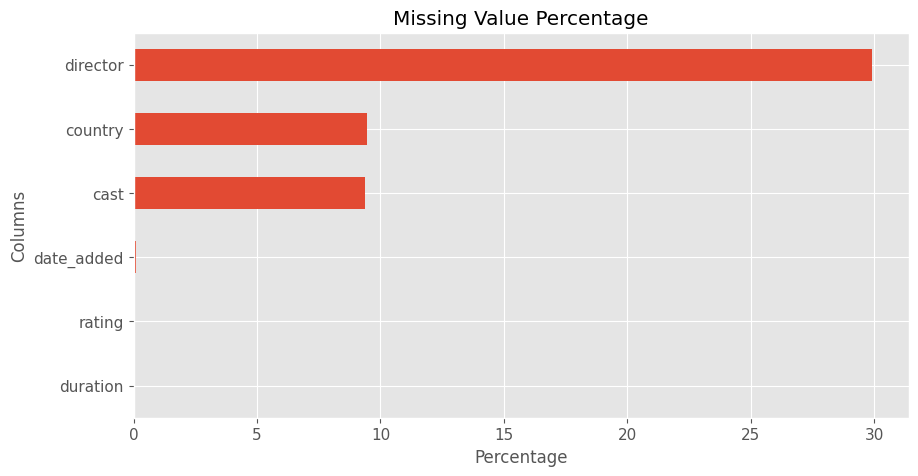

In [16]:
# ==========================================
# Missing Value Plot
# ==========================================

missing_percent.sort_values().plot(
    kind="barh",
    fontsize=11
)

plt.title("Missing Value Percentage")
plt.xlabel("Percentage")
plt.ylabel("Columns")

plt.show()

In [17]:
# ==========================================
# Duplicate Records
# ==========================================

duplicates = df.duplicated().sum()

print("Duplicate Records :", duplicates)

Duplicate Records : 0


In [18]:
# ==========================================
# Movies vs TV Shows
# ==========================================

df["type"].value_counts()

,count
type,
Movie,6131
TV Show,2676


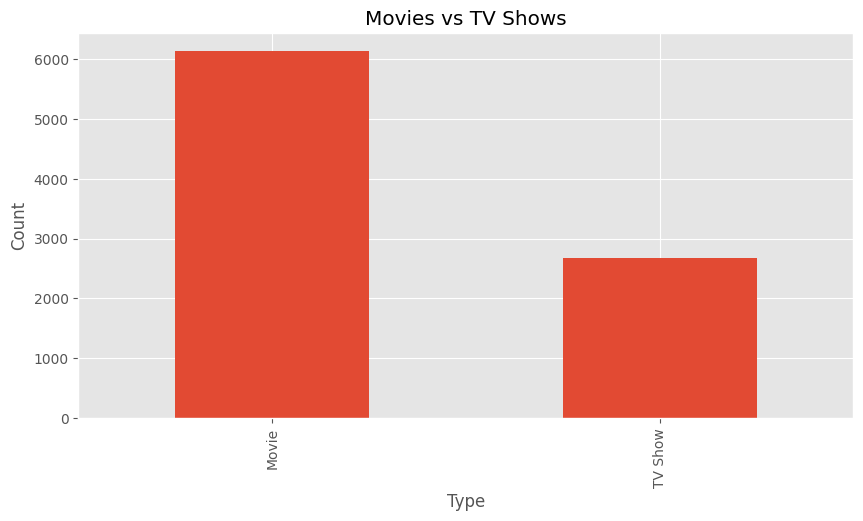

In [19]:
# ==========================================
# Movies vs TV Shows Plot
# ==========================================

df["type"].value_counts().plot(
    kind="bar"
)

plt.title("Movies vs TV Shows")

plt.xlabel("Type")

plt.ylabel("Count")

plt.show()

In [20]:
# ==========================================
# Content Ratings
# ==========================================

df["rating"].value_counts().head(10)

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


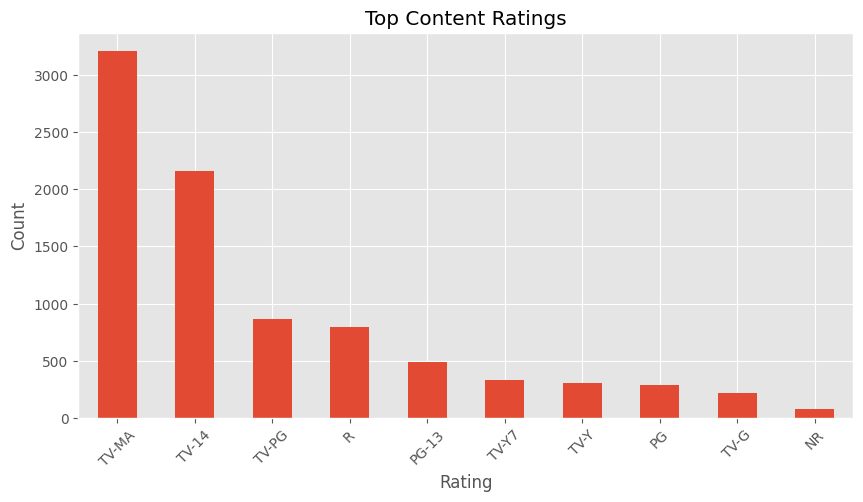

In [21]:
# ==========================================
# Rating Distribution
# ==========================================

df["rating"].value_counts().head(10).plot(
    kind="bar"
)

plt.title("Top Content Ratings")

plt.xlabel("Rating")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

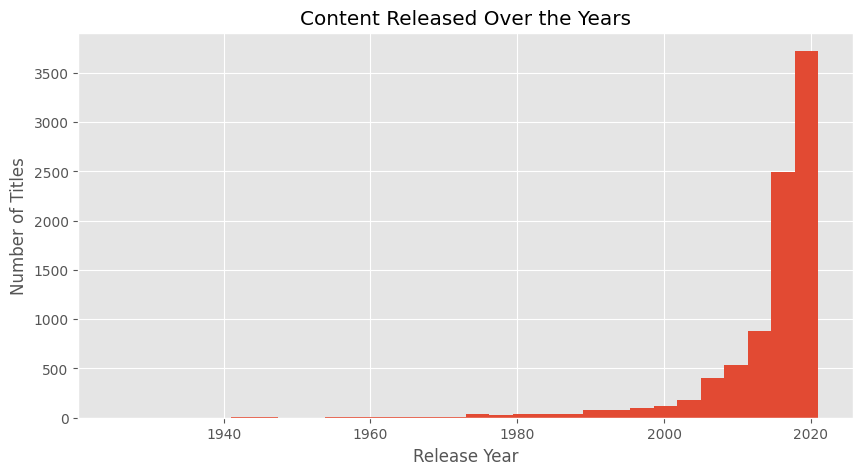

In [22]:
# ==========================================
# Release Year Distribution
# ==========================================

plt.hist(
    df["release_year"],
    bins=30
)

plt.title("Content Released Over the Years")

plt.xlabel("Release Year")

plt.ylabel("Number of Titles")

plt.show()

In [23]:
# ==========================================
# Top Countries
# ==========================================

top_country = df["country"].value_counts().head(10)

top_country

,count
country,
United States,2818
India,972
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124
Mexico,110


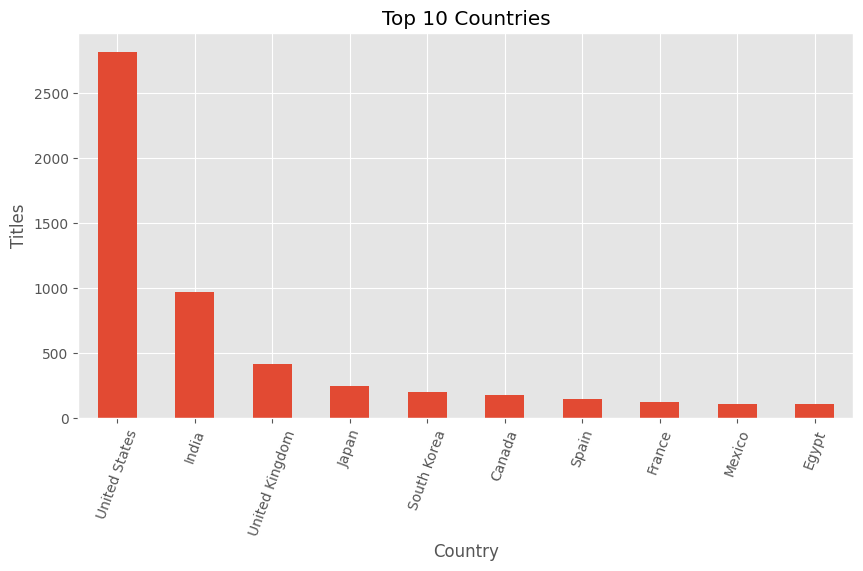

In [24]:
# ==========================================
# Top Countries
# ==========================================

top_country.plot(kind="bar")

plt.title("Top 10 Countries")

plt.xlabel("Country")

plt.ylabel("Titles")

plt.xticks(rotation=70)

plt.show()

In [25]:
# ==========================================
# Top Genres
# ==========================================

genres = (
    df["listed_in"]
    .str.split(", ")
    .explode()
)

genres.value_counts().head(15)

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


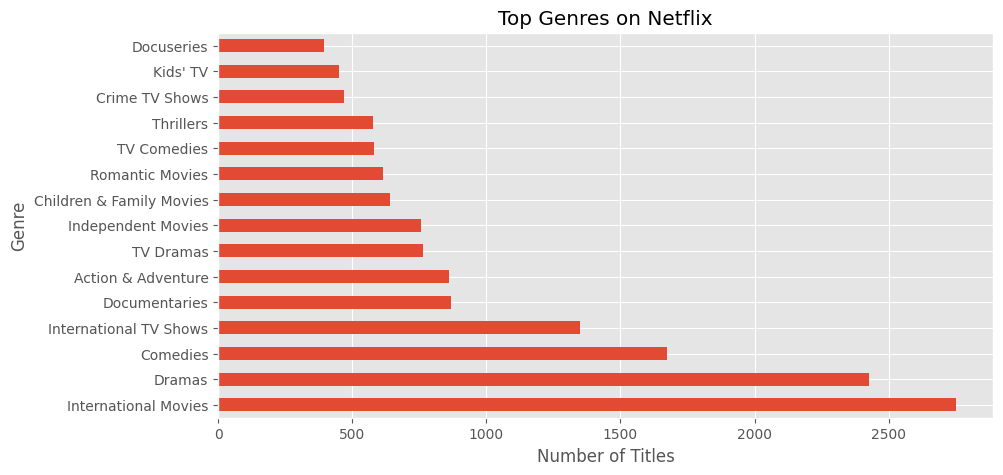

In [26]:
# ==========================================
# Genre Distribution
# ==========================================

genres.value_counts().head(15).plot(
    kind="barh"
)

plt.title("Top Genres on Netflix")

plt.xlabel("Number of Titles")

plt.ylabel("Genre")

plt.show()

In [27]:
# ==========================================
# Top Directors
# ==========================================

directors = (
    df["director"]
    .dropna()
    .str.split(", ")
    .explode()
)

directors.value_counts().head(15)

,count
director,
Rajiv Chilaka,22
Jan Suter,21
Raúl Campos,19
Suhas Kadav,16
Marcus Raboy,16
Jay Karas,15
Cathy Garcia-Molina,13
Martin Scorsese,12
Youssef Chahine,12


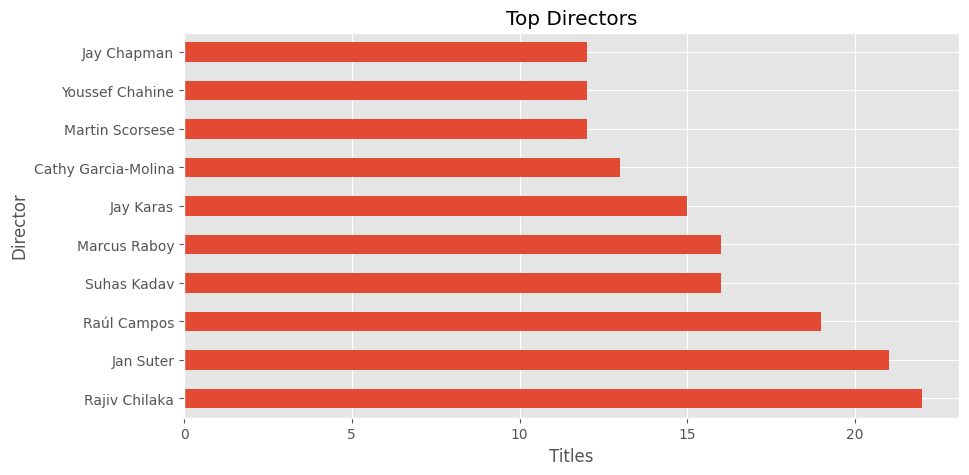

In [28]:
# ==========================================
# Top Directors
# ==========================================

directors.value_counts().head(10).plot(
    kind="barh"
)

plt.title("Top Directors")

plt.xlabel("Titles")

plt.ylabel("Director")

plt.show()

In [29]:
print("""
EDA COMPLETED SUCCESSFULLY

Key Findings

1. Movies dominate Netflix content.

2. Most content was released after 2015.

3. Director and cast columns contain many missing values.

4. International Movies and Dramas are among the most common genres.

5. USA contributes the highest number of titles.

6. Data is suitable for a content-based recommendation system.
""")


EDA COMPLETED SUCCESSFULLY

Key Findings

1. Movies dominate Netflix content.

2. Most content was released after 2015.

3. Director and cast columns contain many missing values.

4. International Movies and Dramas are among the most common genres.

5. USA contributes the highest number of titles.

6. Data is suitable for a content-based recommendation system.



# Stage -- 3

In [30]:
# ==========================================
# Create Backup
# ==========================================

df_clean = df.copy()

print("Backup Created Successfully")

Backup Created Successfully


In [31]:
# ==========================================
# Missing Values
# ==========================================

df_clean.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [32]:
# ==========================================
# Fill Missing Values
# ==========================================

text_columns = [
    "director",
    "cast",
    "country",
    "rating",
    "listed_in",
    "description"
]

for col in text_columns:
    df_clean[col] = df_clean[col].fillna("Unknown")

print("Missing Values Filled")

Missing Values Filled


In [33]:
# ==========================================
# Date Added
# ==========================================

df_clean["date_added"] = df_clean["date_added"].fillna("Unknown")

In [34]:
# ==========================================
# Remove Duplicates
# ==========================================

before = len(df_clean)

df_clean.drop_duplicates(inplace=True)

after = len(df_clean)

print("Duplicates Removed :", before-after)

Duplicates Removed : 0


In [35]:
# ==========================================
# Verify Dataset
# ==========================================

df_clean.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,3


In [36]:
# ==========================================
# Important Features
# ==========================================

features = [

    "title",

    "director",

    "cast",

    "listed_in",

    "description"

]

df_model = df_clean[features]

df_model.head()

,title,director,cast,listed_in,description
0,Dick Johnson Is Dead,Kirsten Johnson,Unknown,Documentaries,"As her father nears the end of his life, filmm..."
1,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...","International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...","Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,Jailbirds New Orleans,Unknown,Unknown,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...","International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [37]:
# ==========================================
# Text Cleaning Function
# ==========================================

def clean_text(text):

    text = str(text)

    text = text.lower()

    text = text.replace(",", " ")

    return text

In [38]:
# ==========================================
# Apply Cleaning
# ==========================================

for column in features:

    df_model[column] = df_model[column].apply(clean_text)

print("Text Cleaning Completed")

Text Cleaning Completed


In [39]:
# ==========================================
# Create Combined Features
# ==========================================

df_model["combined_features"] = (

      df_model["director"]

    + " "

    + df_model["cast"]

    + " "

    + df_model["listed_in"]

    + " "

    + df_model["description"]

)

In [40]:
# Display Sample
df_model[
    [
        "title",
        "combined_features"
    ]
].head()

,title,combined_features
0,dick johnson is dead,kirsten johnson unknown documentaries as her f...
1,blood & water,unknown ama qamata khosi ngema gail mabalane...
2,ganglands,julien leclercq sami bouajila tracy gotoas s...
3,jailbirds new orleans,unknown unknown docuseries reality tv feuds ...
4,kota factory,unknown mayur more jitendra kumar ranjan raj...


In [41]:
# Check Dataset
print(df_model.shape)

df_model.head()

(8807, 6)


,title,director,cast,listed_in,description,combined_features
0,dick johnson is dead,kirsten johnson,unknown,documentaries,as her father nears the end of his life filmm...,kirsten johnson unknown documentaries as her f...
1,blood & water,unknown,ama qamata khosi ngema gail mabalane thaban...,international tv shows tv dramas tv mysteries,after crossing paths at a party a cape town t...,unknown ama qamata khosi ngema gail mabalane...
2,ganglands,julien leclercq,sami bouajila tracy gotoas samuel jouy nabi...,crime tv shows international tv shows tv act...,to protect his family from a powerful drug lor...,julien leclercq sami bouajila tracy gotoas s...
3,jailbirds new orleans,unknown,unknown,docuseries reality tv,feuds flirtations and toilet talk go down amo...,unknown unknown docuseries reality tv feuds ...
4,kota factory,unknown,mayur more jitendra kumar ranjan raj alam k...,international tv shows romantic tv shows tv ...,in a city of coaching centers known to train i...,unknown mayur more jitendra kumar ranjan raj...


In [42]:
# Check Combined Feature Length
df_model["combined_features"].str.len().describe()

,combined_features
count,8807.000000
mean,301.775292
std,79.779609
min,112.000000
25%,245.000000
50%,308.000000
75%,346.000000
max,971.000000


In [43]:
# Save Clean Dataset
df_model.to_csv(
    "clean_netflix_data.csv",
    index=False
)

print("Clean Dataset Saved")

Clean Dataset Saved


# Stage -- 4

In [44]:
# ==========================================
# Recommendation Model Libraries
# ==========================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [45]:
# ==========================================
# TF-IDF Vectorizer
# ==========================================

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=10000
)

In [46]:
# ==========================================
# Create TF-IDF Matrix
# ==========================================

tfidf_matrix = tfidf.fit_transform(df_model["combined_features"])

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (8807, 10000)


In [47]:
# ==========================================
# Cosine Similarity Matrix
# ==========================================

cosine_sim = cosine_similarity(tfidf_matrix)

print("Cosine Similarity Matrix Shape:", cosine_sim.shape)

Cosine Similarity Matrix Shape: (8807, 8807)


In [48]:
# ==========================================
# Title to Index Mapping
# ==========================================

indices = pd.Series(
    df_model.index,
    index=df_model["title"]
).drop_duplicates()

indices.head()

,0
title,
dick johnson is dead,0
blood & water,1
ganglands,2
jailbirds new orleans,3
kota factory,4


In [49]:
# ==========================================
# Recommendation Function
# ==========================================

def recommend_movies(title, top_n=10):

    title = title.lower()

    if title not in indices:
        return ["Movie not found in the dataset."]

    idx = indices[title]

    similarity_scores = list(enumerate(cosine_sim[idx]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:top_n+1]

    movie_indices = [i[0] for i in similarity_scores]


In [50]:
# Test Recommendation
recommend_movies("interstelar")

['Movie not found in the dataset.']

In [51]:
# Test
recommend_movies("extraction")

In [52]:
# Pretty Print Recommendations
movie = "interstelar"

print("="*60)
print(f"Recommendations for: {movie.title()}")
print("="*60)

results = recommend_movies(movie)

for i, rec in enumerate(results, start=1):
    print(f"{i}. {rec.title()}")

Recommendations for: Interstelar
1. Movie Not Found In The Dataset.


In [53]:
# Check Model Performance
print("Number of Titles :", len(df_model))

print("Vocabulary Size :", len(tfidf.vocabulary_))

print("Similarity Matrix Shape :", cosine_sim.shape)

Number of Titles : 8807
Vocabulary Size : 10000
Similarity Matrix Shape : (8807, 8807)


In [54]:
# Save the ML model
import joblib

# Save TF-IDF Model
joblib.dump(tfidf, "tfidf.pkl")

# Save Similarity Matrix
joblib.dump(cosine_sim, "similarity.pkl")

# Save Processed Dataset
joblib.dump(df_model, "movie_data.pkl")

# Save Title Index
joblib.dump(indices, "indices.pkl")

print("All model files saved successfully!")

All model files saved successfully!


# Stage -- 5
Enhanced Recommendation Engine

In [55]:
# Install RapidFuzz
!pip install rapidfuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 10.2 MB/s eta 0:00:00


In [56]:
# Import
from rapidfuzz import process

In [57]:
# Create Search List
movie_titles = df_model["title"].tolist()

In [58]:
# Fuzzy Search Function
def find_movie(movie_name):

    movie_name = movie_name.lower()

    match = process.extractOne(
        movie_name,
        movie_titles,
        score_cutoff=60
    )

    if match:
        return match[0]

    return None

In [59]:
# Enhanced Recommendation Function
def recommend_movies(movie_name, top_n=10):

    movie = find_movie(movie_name)

    if movie is None:
        return None

    idx = indices[movie]

    similarity_scores = list(enumerate(cosine_sim[idx]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )[1:top_n+1]

    recommendations = []

    for index, score in similarity_scores:

        recommendations.append({

            "Title": df_model.iloc[index]["title"].title(),

            "Genres": df_clean.iloc[index]["listed_in"],

            "Director": df_clean.iloc[index]["director"],

            "Description": df_clean.iloc[index]["description"],

            "Similarity": round(float(score),3)

        })

    return recommendations

In [60]:
# Test
recommend_movies("interstelar")

[{'Title': 'Code 8',
  'Genres': 'Action & Adventure, Independent Movies, International Movies',
  'Director': 'Jeff Chan',
  'Description': 'In a city where super-powered people are ostracized, an earnest day laborer considers using his outlawed abilities for money to save his sick mother.',
  'Similarity': 0.173},
 {'Title': 'When We First Met',
  'Genres': 'Comedies, Romantic Movies',
  'Director': 'Ari Sandel',
  'Description': 'Using a magical photo booth that sends him back in time, Noah relives the night he met Avery over and over, trying to persuade her to fall for him.',
  'Similarity': 0.155},
 {'Title': 'The Endless',
  'Genres': 'Independent Movies, Sci-Fi & Fantasy, Thrillers',
  'Director': 'Justin Benson, Aaron Moorhead',
  'Description': 'As kids, they escaped a UFO death cult. Now, two adult brothers seek answers after an old videotape surfaces and brings them back to where they began.',
  'Similarity': 0.137},
 {'Title': 'Grizzlies',
  'Genres': 'Dramas, Independent M

In [61]:
# Pretty Print
movie = input("Enter Movie Name: ")

results = recommend_movies(movie)

if results is None:

    print("Movie Not Found")

else:

    print("="*80)

    print(f"Recommendations for {movie.title()}")

    print("="*80)

    for i, rec in enumerate(results,1):

        print(f"\n{i}. {rec['Title']}")

        print(f"Genre      : {rec['Genres']}")

        print(f"Director   : {rec['Director']}")

        print(f"Similarity : {rec['Similarity']}")

        print(f"Description: {rec['Description']}")

Enter Movie Name: fronteras
Recommendations for Fronteras

1. Hunt To Kill
Genre      : Action & Adventure
Director   : Keoni Waxman
Similarity : 0.143
Description: U.S. Border Patrol agent and deadly hunter Jim Rhodes takes violent revenge when a group of desperate thieves kidnaps his daughter after a robbery.

2. Border Patrol
Genre      : Reality TV
Director   : Unknown
Similarity : 0.139
Description: This reality TV series follows the men and women of New Zealand's border patrol in their quest to keep their country safe and secure.

3. Pareeth Pandaari
Genre      : Dramas, Independent Movies, International Movies
Director   : Gafoor Y. Elliyaas
Similarity : 0.125
Description: As the parents of three unmarried daughters, a humble cook and his wife contend with the challenges of matchmaking and social expectations.

4. Extraction
Genre      : Action & Adventure
Director   : Steven C. Miller
Similarity : 0.124
Description: When a retired CIA agent is kidnapped, his son, a government a

In [62]:
# Save Everything
import joblib

joblib.dump(df_model, "movie_data.pkl")
joblib.dump(df_clean, "clean_movie_data.pkl")
joblib.dump(cosine_sim, "similarity.pkl")
joblib.dump(tfidf, "tfidf.pkl")
joblib.dump(indices, "indices.pkl")

['indices.pkl']

In [63]:
import os

files = [
    "movie_data.pkl",
    "clean_movie_data.pkl",
    "similarity.pkl",
    "tfidf.pkl",
    "indices.pkl"
]

for file in files:
    if os.path.exists(file):
        print(f"✅ {file} exists")
    else:
        print(f"❌ {file} NOT found")

✅ movie_data.pkl exists
✅ clean_movie_data.pkl exists
✅ similarity.pkl exists
✅ tfidf.pkl exists
✅ indices.pkl exists


# Stage -- 6

In [64]:
%%writefile recommender.py

import pickle
import pandas as pd
from difflib import get_close_matches


class NetflixRecommender:

    def __init__(self):
        self.df = None
        self.similarity = None
        self.indices = None

    def load_models(self):

        with open("clean_movie_data.pkl", "rb") as f:
            self.df = pickle.load(f)

        with open("similarity.pkl", "rb") as f:
            self.similarity = pickle.load(f)

        with open("indices.pkl", "rb") as f:
            self.indices = pickle.load(f)

    def recommend(self, movie_name, top_n=10):

        movie_name = movie_name.strip()

        if movie_name not in self.indices:

            matches = get_close_matches(
                movie_name,
                self.indices.keys(),
                n=1,
                cutoff=0.6
            )

            if not matches:
                return []

            movie_name = matches[0]

        idx = self.indices[movie_name]

        sim_scores = list(enumerate(self.similarity[idx]))

        sim_scores = sorted(
            sim_scores,
            key=lambda x: x[1],
            reverse=True
        )[1:top_n+1]

        recommendations = []

        for i, score in sim_scores:

            movie = self.df.iloc[i]

            recommendations.append({

                "Title": movie["title"],
                "Genre": movie["listed_in"],
                "Director": movie["director"],
                "Description": movie["description"],
                "Similarity": round(score, 3)

            })

        return recommendations

Writing recommender.py


In [65]:
from recommender import NetflixRecommender

model = NetflixRecommender()
print(model)